---
# LHC tracking, extracting invariant tori
---

In [1]:
import json
import pathlib
import numpy as np
import pytori as pt
import nafflib

import xobjects as xo
import xtrack as xt


# Loading XTRACK example line
#========================================
xt_data_folder  = pathlib.Path(xt.__file__).parent.joinpath('../test_data').absolute()
line_fname      = xt_data_folder.joinpath('./lhc_no_bb/line_and_particle.json')
with open(line_fname, 'r') as fid:
    line_data = json.load(fid)
#========================================


# BEAM & XSUITE LINE
#=========================================================================================
nrj             = 7000e9
particle_ref    = xt.Particles(p0c=nrj, q0=1, mass0=xt.PROTON_MASS_EV)
context         = xo.ContextCpu(omp_num_threads='auto')
nemitt_x        = 2.5e-6
nemitt_y        = 2.5e-6
gemitt_x        = 1 if nemitt_x is None else ( nemitt_x / particle_ref.beta0[0] / particle_ref.gamma0[0])
gemitt_y        = 1 if nemitt_y is None else ( nemitt_y / particle_ref.beta0[0] / particle_ref.gamma0[0])
#-----------------------------------------------------------------------------------------
context = xo.ContextCpu()
line    = xt.Line.from_dict(line_data['line'])
line.particle_ref = particle_ref
line.build_tracker(_context=context)
line.freeze_longitudinal(True)
twiss       = line.twiss4d()
#=========================================================================================


Loading line from dict:   0%|          | 0/18657 [00:00<?, ?it/s]

Done loading line from dict.           
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


---
# Constructing tori from tracking (all particles at once)
---

In [2]:
num_turns = int(1e4)

# Initialize particles in CS-normalized phase space
#=======================================================================
particles = line.build_particles(   x_norm   = [1,3,5,7,9],
                                    y_norm   = [3,3,3,3,3],
                                    method   = '4d',
                                    nemitt_x = nemitt_x,
                                    nemitt_y = nemitt_y,
                                    nemitt_zeta     = None,
                                    W_matrix        = twiss.W_matrix[0],
                                    particle_on_co  = twiss.particle_on_co.copy(),
                                    _context        = context)
line.track(particles, num_turns= num_turns,turn_by_turn_monitor=True,with_progress=True)
#=======================================================================

#=======================================================================
naff_buffer = pt.NAFFMonitor()
#---------------------------------------------------------
naff_buffer.twiss        = twiss.get_twiss_init(at_element=twiss.name[0])
naff_buffer.nemitt_x     = nemitt_x
naff_buffer.nemitt_y     = nemitt_y
naff_buffer.nemitt_zeta  = None 
#---------------------------------------------------------
naff_buffer.n_harm       = 100
naff_buffer.window_order = 4
naff_buffer.window_type  = 'hann'
naff_buffer.multiprocesses = 8 # Number of processes for parallel processing
#=======================================================================
# Processing
naff_buffer.process(monitor=line.record_last_track)
naff_df = naff_buffer.to_pandas().groupby('start_at_turn').get_group(0).set_index('particle')
#=======================================================================

trk_tori = []
for pid, naff_row in naff_df.iterrows():

    # Indexing harmonics
    #============================================================================
    max_n       = 90
    max_alias   = 50
    warning_tol = 1e-7
    Qvec = [naff_row.Qx[0],naff_row.Qy[0]]
    nx  = nafflib.linear_combinations(naff_row.Qx,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
    ny  = nafflib.linear_combinations(naff_row.Qy,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
    #============================================================================

    _torus = pt.Torus.from_naff(n=[nx,ny],A=[naff_row.Ax,naff_row.Ay])
    trk_tori.append(_torus)
    display(_torus)


Tracking:   0%|          | 0/10000 [00:00<?, ?it/s]

/Users/pbelanger/ABPLocal/nafflib/nafflib/indexing.py:165: UserWarning: Large frequency error, consider increasing max_n or max_alias!
  warnings.warn('Large frequency error, consider increasing max_n or max_alias!')


╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭────────────────────────── x ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 1, 0)  -9.90851e-01 - 4.62588e-03j  9.90862e-01   │                                                           │
│  │   ( 0,-2)  -3.22334e-03 - 1.77978e-03j  3.68206e-03   │                                                           │
│  │   (-1, 2)   2.07365e-03 + 1.73193e-03j  2.70178e-03   │                                                           │
│  │   (-1,-1)   8.66563e-04 + 1.59435e-03j  1.81463e-03   │                                                           │
│  │   ( 0, 0)   6.78307e-04 + 1.53688e-03j  1.67991e-03   │                                                           │
│  │   ( 0, 2)  -1.51558e-03 - 2.93538e-04j  1.54375e-03   │                                                           │
│  │   (-2, 0)   8.34917e-05 + 1.45862e-03j  1.46101e-03   │                                                           │
│  │   ( 0, 1)  -3.82439e-04 - 8.85491e-04j  9.64549e-04   │                                                           │
│  │   (-1, 1)   3.08815e-04 + 5.86683e-04j  6.62996e-04   │                                                           │
│  │   ( 2,-1)   4.18476e-04 + 2.27797e-04j  4.76459e-04   │                                                           │
│  │   ...      ...                          ...           │                                                           │
│  │                                                       │                                                           │
│  ╰────────────────────── terms=100 ──────────────────────╯                                                           │
│  ╭────────────────────────── y ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 0, 1)   2.99886e+00 + 7.45082e-04j  2.99886e+00   │                                                           │
│  │   (-1,-1)  -2.15331e-03 - 1.16639e-03j  2.44892e-03   │                                                           │
│  │   ( 0,-2)   1.18102e-03 + 3.09350e-04j  1.22086e-03   │                                                           │
│  │   ( 1,-1)  -9.98294e-04 - 1.86747e-04j  1.01561e-03   │                                                           │
│  │   ( 0, 0)  -8.32944e-04 - 4.72112e-04j  9.57437e-04   │                                                           │
│  │   ( 2,-1)   6.54077e-04 + 5.46762e-04j  8.52505e-04   │                                                           │
│  │   ( 1, 0)  -1.48514e-04 - 7.86161e-04j  8.00066e-04   │                                                           │
│  │   ( 1, 1)   3.91183e-04 + 5.65203e-04j  6.87371e-04   │                                                           │
│  │   (-1, 1)   3.89507e-04 + 5.63697e-04j  6.85179e-04   │                                                           │
│  │   ( 0, 2)  -3.89514e-04 - 2.85197e-04j  4.82761e-04   │                                                           │
│  │   ...      ...                          ...           │                                                           │
│  │                                                       │                                                           │
│  ╰───

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭────────────────────────── x ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 1, 0)  -2.98900e+00 - 3.19479e-02j  2.98917e+00   │                                                           │
│  │   (-2, 0)   7.14745e-04 + 1.35315e-02j  1.35504e-02   │                                                           │
│  │   (-1, 2)   6.97410e-03 + 5.85132e-03j  9.10363e-03   │                                                           │
│  │   ( 0, 1)   8.09133e-03 + 3.40573e-03j  8.77888e-03   │                                                           │
│  │   (-1,-1)   2.45484e-03 + 5.05010e-03j  5.61513e-03   │                                                           │
│  │   ( 2,-1)   4.54633e-03 + 2.37855e-03j  5.13095e-03   │                                                           │
│  │   ( 0,-2)  -3.17292e-03 - 1.76013e-03j  3.62842e-03   │                                                           │
│  │   ( 0, 0)   3.51992e-03 + 1.36089e-04j  3.52255e-03   │                                                           │
│  │   ( 2, 0)  -2.33667e-03 - 8.28265e-04j  2.47912e-03   │                                                           │
│  │   (-1, 1)   8.76238e-04 + 1.79700e-03j  1.99925e-03   │                                                           │
│  │   ...      ...                          ...           │                                                           │
│  │                                                       │                                                           │
│  ╰────────────────────── terms=99 ───────────────────────╯                                                           │
│  ╭────────────────────────── y ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 0, 1)  -2.99865e+00 - 5.79879e-03j  2.99866e+00   │                                                           │
│  │   ( 2,-1)   6.32311e-03 + 5.40254e-03j  8.31680e-03   │                                                           │
│  │   (-1,-1)  -6.41679e-03 - 3.51409e-03j  7.31601e-03   │                                                           │
│  │   ( 1,-1)  -3.04139e-03 - 5.59617e-04j  3.09245e-03   │                                                           │
│  │   ( 1, 0)  -2.78480e-03 - 7.60847e-04j  2.88687e-03   │                                                           │
│  │   (-2, 0)   1.24009e-03 + 2.44058e-03j  2.73756e-03   │                                                           │
│  │   (-1, 1)   1.17443e-03 + 1.71770e-03j  2.08081e-03   │                                                           │
│  │   ( 1, 1)   1.16784e-03 + 1.71708e-03j  2.07659e-03   │                                                           │
│  │   (-1, 2)  -8.76627e-04 - 1.57328e-03j  1.80102e-03   │                                                           │
│  │   ( 0,-2)   1.25782e-03 + 2.21134e-04j  1.27711e-03   │                                                           │
│  │   ...      ...                          ...           │                                                           │
│  │                                                       │                                                           │
│  ╰───

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭────────────────────────── x ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 1, 0)  -4.99246e+00 - 9.08686e-02j  4.99329e+00   │                                                           │
│  │   (-2, 0)   2.11956e-03 + 3.93096e-02j  3.93667e-02   │                                                           │
│  │   ( 0, 1)   3.13542e-02 + 1.64839e-02j  3.54232e-02   │                                                           │
│  │   ( 2,-1)   1.85943e-02 + 9.33883e-03j  2.08077e-02   │                                                           │
│  │   (-1, 2)   1.51392e-02 + 1.25372e-02j  1.96565e-02   │                                                           │
│  │   ( 0, 0)  -1.18903e-02 - 2.75965e-03j  1.22063e-02   │                                                           │
│  │   (-1,-1)   3.60384e-03 + 9.06310e-03j  9.75333e-03   │                                                           │
│  │   ( 2, 0)  -6.43700e-03 - 2.46100e-03j  6.89141e-03   │                                                           │
│  │   ( 0,-2)  -3.14704e-03 - 1.66724e-03j  3.56139e-03   │                                                           │
│  │   (-1, 1)   1.31531e-03 + 3.07249e-03j  3.34219e-03   │                                                           │
│  │   ...      ...                          ...           │                                                           │
│  │                                                       │                                                           │
│  ╰────────────────────── terms=100 ──────────────────────╯                                                           │
│  ╭────────────────────────── y ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 0, 1)  -2.99306e+00 - 2.82537e-02j  2.99319e+00   │                                                           │
│  │   ( 2,-1)   2.04783e-02 + 1.78294e-02j  2.71523e-02   │                                                           │
│  │   ( 1, 0)   1.87564e-02 + 5.36227e-03j  1.95078e-02   │                                                           │
│  │   (-1,-1)  -1.04472e-02 - 5.91995e-03j  1.20079e-02   │                                                           │
│  │   (-2, 0)   3.08732e-03 + 7.35055e-03j  7.97259e-03   │                                                           │
│  │   (-1, 2)  -3.76098e-03 - 4.35164e-03j  5.75167e-03   │                                                           │
│  │   ( 1,-1)  -5.16719e-03 - 9.63160e-04j  5.25619e-03   │                                                           │
│  │   (-1, 1)   1.98571e-03 + 2.90842e-03j  3.52164e-03   │                                                           │
│  │   ( 1, 1)   1.91516e-03 + 2.88987e-03j  3.46687e-03   │                                                           │
│  │   ( 0, 0)   2.23104e-03 + 1.87647e-03j  2.91525e-03   │                                                           │
│  │   ...      ...                          ...           │                                                           │
│  │                                                       │                                                           │
│  ╰───

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭────────────────────────── x ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 1, 0)  -7.00286e+00 - 2.39202e-01j  7.00695e+00   │                                                           │
│  │   ( 0, 1)   1.09162e-01 + 6.30444e-02j  1.26059e-01   │                                                           │
│  │   (-2, 0)   4.04019e-03 + 8.28623e-02j  8.29608e-02   │                                                           │
│  │   ( 2,-1)   7.47311e-02 + 3.59955e-02j  8.29483e-02   │                                                           │
│  │   (-1, 2)   3.62275e-02 + 2.88643e-02j  4.63204e-02   │                                                           │
│  │   ( 0, 0)  -2.43693e-02 - 7.31693e-03j  2.54441e-02   │                                                           │
│  │   ( 3,-2)   9.14468e-03 + 9.94272e-03j  1.35086e-02   │                                                           │
│  │   ( 2, 0)  -1.23787e-02 - 5.35759e-03j  1.34884e-02   │                                                           │
│  │   (-1,-1)   4.27661e-03 + 1.26884e-02j  1.33897e-02   │                                                           │
│  │   (-1, 1)   1.62335e-03 + 4.41287e-03j  4.70198e-03   │                                                           │
│  │   ...      ...                          ...           │                                                           │
│  │                                                       │                                                           │
│  ╰────────────────────── terms=100 ──────────────────────╯                                                           │
│  ╭────────────────────────── y ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 0, 1)  -2.96050e+00 - 8.08486e-02j  2.96160e+00   │                                                           │
│  │   ( 1, 0)   7.59012e-02 + 2.80120e-02j  8.09053e-02   │                                                           │
│  │   ( 2,-1)   5.36488e-02 + 4.82521e-02j  7.21558e-02   │                                                           │
│  │   (-1, 2)  -1.64117e-02 - 1.50880e-02j  2.22933e-02   │                                                           │
│  │   (-2, 0)   4.81090e-03 + 1.59973e-02j  1.67050e-02   │                                                           │
│  │   (-1,-1)  -1.42306e-02 - 8.55221e-03j  1.66028e-02   │                                                           │
│  │   ( 1,-1)  -7.38417e-03 - 1.43660e-03j  7.52262e-03   │                                                           │
│  │   ( 0, 0)   4.18596e-03 + 4.41624e-03j  6.08486e-03   │                                                           │
│  │   (-2, 3)  -4.33675e-03 - 3.65482e-03j  5.67143e-03   │                                                           │
│  │   ( 2, 0)   1.81474e-03 + 5.29150e-03j  5.59404e-03   │                                                           │
│  │   ...      ...                          ...           │                                                           │
│  │                                                       │                                                           │
│  ╰───

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭────────────────────────── x ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 1, 0)  -8.93729e+00 - 1.13908e+00j  9.00958e+00   │                                                           │
│  │   ( 0, 1)   7.26150e-01 + 4.63921e-01j  8.61694e-01   │                                                           │
│  │   ( 2,-1)   6.65129e-01 + 1.89186e-01j  6.91512e-01   │                                                           │
│  │   (-1, 2)   1.65137e-01 + 1.44743e-01j  2.19592e-01   │                                                           │
│  │   (-2, 0)   1.38085e-02 + 1.52365e-01j  1.52990e-01   │                                                           │
│  │   ( 3,-2)   3.19961e-02 + 1.45600e-01j  1.49075e-01   │                                                           │
│  │   ( 0, 0)  -4.13262e-02 - 1.40501e-02j  4.36493e-02   │                                                           │
│  │   ( 4,-3)   2.39546e-02 + 1.83556e-02j  3.01787e-02   │                                                           │
│  │   (-3, 1)   5.08708e-03 + 2.18235e-02j  2.24086e-02   │                                                           │
│  │   ( 2, 0)  -1.82182e-02 - 1.20764e-02j  2.18573e-02   │                                                           │
│  │   ...      ...                          ...           │                                                           │
│  │                                                       │                                                           │
│  ╰────────────────────── terms=100 ──────────────────────╯                                                           │
│  ╭────────────────────────── y ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 0, 1)  -2.69688e+00 - 1.27047e-01j  2.69987e+00   │                                                           │
│  │   ( 1, 0)   3.63805e-01 + 5.57565e-02j  3.68053e-01   │                                                           │
│  │   ( 2,-1)   1.45276e-01 + 1.79708e-01j  2.31084e-01   │                                                           │
│  │   (-1, 2)  -1.40982e-01 - 1.16382e-01j  1.82813e-01   │                                                           │
│  │   (-2, 3)  -2.36410e-02 - 3.95710e-02j  4.60951e-02   │                                                           │
│  │   (-2, 0)   1.91377e-03 + 2.88555e-02j  2.89189e-02   │                                                           │
│  │   ( 3,-2)   2.46724e-02 + 1.04550e-02j  2.67962e-02   │                                                           │
│  │   (-1,-1)  -1.97112e-02 - 1.37414e-02j  2.40282e-02   │                                                           │
│  │   ( 0, 0)   7.69254e-03 + 8.06126e-03j  1.11427e-02   │                                                           │
│  │   ( 2, 0)   1.08293e-03 + 9.85452e-03j  9.91385e-03   │                                                           │
│  │   ...      ...                          ...           │                                                           │
│  │                                                       │                                                           │
│  ╰───

### NAFFMonitor applies NAFF in the CS-normalized phase space

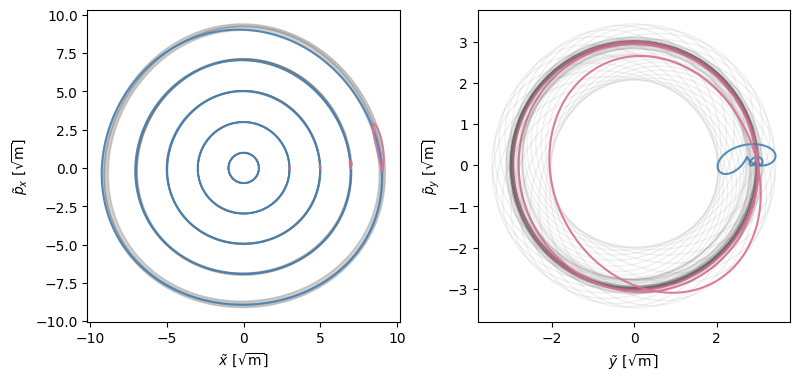

In [3]:
import matplotlib.pyplot as plt
import pytori.plotting as ptplt


# Plotting
#--------------------------------------------------
x_color = 'steelblue'
y_color = 'palevioletred'

fig, axes = plt.subplots(1, 2, figsize=(8.1,4))

# TORUS SHADOW, plotting all possible angle values
#=======================================================
T_loop = np.linspace(0,2*np.pi,100)
T_vals = np.linspace(0,2*np.pi,30)

for torus in trk_tori:

    plt.sca(axes[0])
    for T0 in T_vals[:-1]:
        ptplt.loop(torus,proj='x',Tx=T_loop,Ty=T0,edgecolor='dimgrey',alpha=0.1,lw=1)

    plt.sca(axes[1])
    for T0 in T_vals[:-1]:
        ptplt.loop(torus,proj='y',Tx=T0,Ty=T_loop,edgecolor='dimgrey',alpha=0.1,lw=1)
    #=======================================================


    # Plotting a specific loop
    #=======================================================
    plt.sca(axes[0])
    # same as ptplt.xloop(torus,looping='x')
    ptplt.loop(torus,proj='x',looping='x',edgecolor=x_color,alpha=0.9,lw=1.5)
    ptplt.loop(torus,proj='x',looping='y',edgecolor=y_color,alpha=0.9,lw=1.5)

    plt.sca(axes[1])
    # same as ptplt.yloop(torus,looping='x')
    ptplt.loop(torus,proj='y',looping='x',edgecolor=x_color,alpha=0.9,lw=1.5)
    ptplt.loop(torus,proj='y',looping='y',edgecolor=y_color,alpha=0.9,lw=1.5)


for ax,plane in zip(axes,['x','y']):
    plt.sca(ax)
    plt.axis('equal')
    plt.gca().set_box_aspect(1) 
    plt.xlabel(rf'$\tilde {plane}\ [\sqrt{{\mathrm{{m}}}}]$');
    plt.ylabel(rf'$\tilde p_{plane}\ [\sqrt{{\mathrm{{m}}}}]$');
plt.tight_layout()

### We can transform to physical phase space if desired


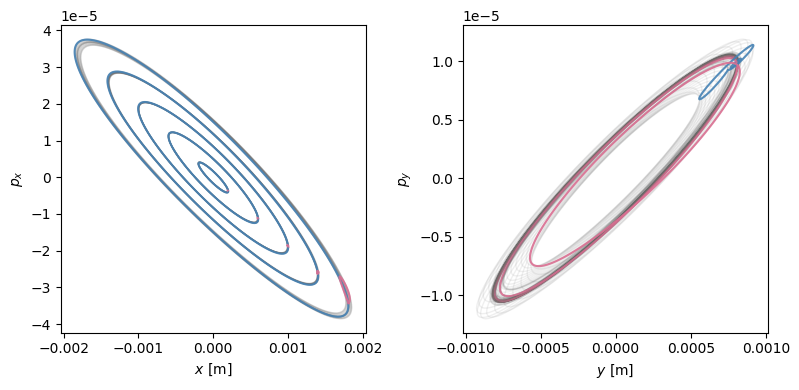

In [4]:
phys_tori = []
for torus in trk_tori:
    # Conversion to physical coordinates
    _torus = pt.transforms.norm2phys(torus.copy(),
                                    W_matrix=twiss.W_matrix[0][:4,:4],
                                    nemitt_x=nemitt_x, 
                                    nemitt_y=nemitt_y, 
                                    particle_on_co=twiss.particle_on_co.copy())
    phys_tori.append(_torus)
    

# Plotting
#--------------------------------------------------
x_color = 'steelblue'
y_color = 'palevioletred'

fig, axes = plt.subplots(1, 2, figsize=(8.1,4))

# TORUS SHADOW, plotting all possible angle values
#=======================================================
T_loop = np.linspace(0,2*np.pi,100)
T_vals = np.linspace(0,2*np.pi,30)

for torus in phys_tori:
    plt.sca(axes[0])
    for T0 in T_vals[:-1]:
        ptplt.loop(torus,proj='x',Tx=T_loop,Ty=T0,edgecolor='dimgrey',alpha=0.1,lw=1)

    plt.sca(axes[1])
    for T0 in T_vals[:-1]:
        ptplt.loop(torus,proj='y',Tx=T0,Ty=T_loop,edgecolor='dimgrey',alpha=0.1,lw=1)
    #=======================================================


    # Plotting a specific loop
    #=======================================================
    plt.sca(axes[0])
    # same as ptplt.xloop(torus,looping='x')
    ptplt.loop(torus,proj='x',looping='x',edgecolor=x_color,alpha=0.9,lw=1.5)
    ptplt.loop(torus,proj='x',looping='y',edgecolor=y_color,alpha=0.9,lw=1.5)

    plt.sca(axes[1])
    # same as ptplt.yloop(torus,looping='x')
    ptplt.loop(torus,proj='y',looping='x',edgecolor=x_color,alpha=0.9,lw=1.5)
    ptplt.loop(torus,proj='y',looping='y',edgecolor=y_color,alpha=0.9,lw=1.5)


for ax,plane in zip(axes,['x','y']):
    plt.sca(ax)
    plt.xlabel(rf'${plane}\ [\mathrm{{m}}]$');
    plt.ylabel(rf'$p_{plane}$');
plt.tight_layout()

---
# Transport spectrum to new location
---

In [ ]:
#=======================================================================
# Let's fix radius in CS-normalized phase space
rx_vec = np.array([0.1,1,2,3])
ry_vec = np.array([0.1,1,2,3])/2

CS_tori = []
for rx,ry in zip(rx_vec,ry_vec):
    CS_tori.append(pt.Torus(x={(1,0):rx},
                            y={(0,1):ry}))
#=======================================================================


# Create correponding particles
#=======================================================================
num_turns = int(1e4)
#--------------
# Dummy sampling rates to distribute particles on the torus
fx  = 1/2/np.sqrt(2)
fy  = 1/2/np.sqrt(3)
# Angle variables for sampling points on the torus
T_N = {'Tx':2*np.pi*fx*np.arange(num_turns),
       'Ty':2*np.pi*fy*np.arange(num_turns)}
#--------------

init_coord = {'x_n':[],'px_n':[],'y_n':[],'py_n':[],'zeta_n':[],'pzeta_n':[]}
for torus in CS_tori:
    init_coord[f'x_n']  += list(torus.X(**T_N))
    init_coord[f'px_n'] += list(torus.PX(**T_N))
    init_coord[f'y_n']  += list(torus.Y(**T_N))
    init_coord[f'py_n'] += list(torus.PY(**T_N))
#=======================================================================


# TRACKING
#=======================================================================
particles = line.build_particles(   x_norm   = init_coord['x_n'],
                                    px_norm  = init_coord['px_n'],
                                    y_norm   = init_coord['y_n'],
                                    py_norm  = init_coord['py_n'],
                                    method   = '4d',
                                    nemitt_x = nemitt_x,
                                    nemitt_y = nemitt_y,
                                    nemitt_zeta     = None,
                                    W_matrix        = twiss.W_matrix[0],
                                    particle_on_co  = twiss.particle_on_co.copy(),
                                    _context        = context)
line.track(particles, num_turns= 1,turn_by_turn_monitor=True,with_progress=True)
#=======================================================================
